# 7. Ground truth for RWC-R: chord labels from aligned MIDI

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-GITHUB-USER/chord-recognition-book/blob/main/notebooks/07_ground_truth_from_midi.ipynb)

> **Paper ↔ code.** Section IV-A evaluates on RWC-R against chord labels reduced to major/minor triads, and notes that the RWC-R MIDI files are aligned to the audio. The annotation repository has **no** chord labels for RWC-R, so this notebook builds them from the aligned MIDI — and first checks the procedure on RWC-P, where human labels exist. Functions: `midi_chords.derive_chords`, `midi_chords.pitch_class_activity`, `midi_chords.bass_pitch_class`, `evaluate.labels_to_frames`.

Only the annotation repository is needed here (no audio download).

In [1]:
# --- Setup: works locally (run from anywhere inside the repository) and on Google Colab ---
import os, sys, pathlib, subprocess

REPO = "YOUR-GITHUB-USER/chord-recognition-book"   # <-- change this after forking

if "google.colab" in sys.modules:
    root = pathlib.Path("/content") / REPO.split("/")[1]
    if not root.exists():
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", str(root)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(root)], check=True)
else:
    root = pathlib.Path.cwd().resolve()
    while not (root / "chordlab").exists() and root != root.parent:
        root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import IPython.display as ipd

import chordlab
from chordlab import data, features, templates, hmm, evaluate, midi_chords, synth, plots

plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["figure.dpi"] = 110
print(f"chordlab {chordlab.__version__} loaded from {root}")
print("data folder:", data.data_root())

chordlab 0.1.0 loaded from /home/claude/chord-recognition-book
data folder: /home/claude/chord-recognition-book/data


## 7.1 The problem

Notebook 1 showed the inventory: curated chords exist for RWC-P only. For RWC-R we have beats and *audio-aligned* MIDI — full arrangements with piano, bass, guitar, strings and a `Melo` track carrying the tune. If the MIDI tells us which notes sound when, we can label chords *symbolically* and, because the MIDI is aligned to the recording, use those labels as ground truth on the audio time axis.

The recipe:

1. Cut the track into **beats** (or bars) using the beat annotation.
2. For each beat, sum how long (× velocity) each of the 12 pitch classes sounds in the non-drum tracks — a *symbolic chroma*.
3. Match that vector to the 24 triad templates with cosine similarity, exactly like the audio decoder. Let the **bass** (lowest sounding note) break ties, because A-C-E-G contains both A:min and C:maj.
4. Mark beats with fewer than two active pitch classes as `N`, remove one-beat blips, merge equal neighbours.

In [2]:
ann = data.ensure_annotations()
meta = data.load_metadata(ann)
rid = "RWC_R007"
pm = midi_chords.load_midi(data.midi_path(rid, ann))
print(meta.loc[rid, "Title"], "—", meta.loc[rid, "Artist"], f"| MIDI ends at {pm.get_end_time():.1f} s, audio_end = {meta.loc[rid, 'audio_end']:.1f} s")
pd.DataFrame([{"track": i.name.strip(), "program": i.program, "drum": i.is_drum, "notes": len(i.notes),
               "lowest": min(n.pitch for n in i.notes), "highest": max(n.pitch for n in i.notes)} for i in pm.instruments])

Mary Had A Little Lamb — Donna Burke | MIDI ends at 119.1 s, audio_end = 119.2 s


,track,program,drum,notes,lowest,highest
0,PIANO,0,False,426,41,70
1,Bass,33,False,134,29,43
2,Guitar,25,False,404,36,67
3,Melo,22,False,103,63,72
4,Horn,60,False,299,51,68
5,Glocken,9,False,106,77,89
6,Flute,73,False,86,70,89
7,Trumpet,56,False,60,65,82
8,Trombone,57,False,120,45,65
9,Drums,0,True,400,36,51


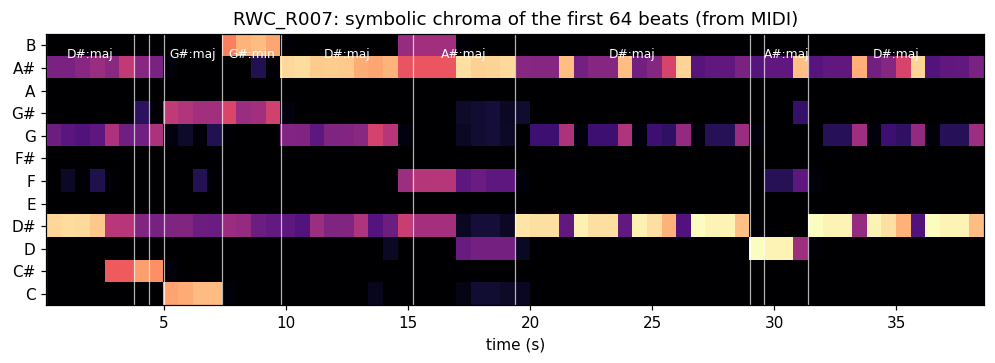

In [3]:
beats, beat_pos = data.load_beats(rid, ann)
intervals = midi_chords.beat_grid(beats, end_time=float(meta.loc[rid, "audio_end"]))
activity = midi_chords.pitch_class_activity(pm, intervals)           # (12, n_beats), drums and 'Melo' excluded
bass = midi_chords.bass_pitch_class(pm, intervals)
act_b = midi_chords.add_bass_bonus(activity, bass, bonus=0.5)
states, conf = midi_chords.label_activity(act_b)

fig, ax = plt.subplots(figsize=(11, 3.2))
plots.plot_chroma(features.l2_normalize(act_b[:, :64]), intervals[:64, 0], ax=ax, title=f"{rid}: symbolic chroma of the first 64 beats (from MIDI)")
labels_beat = [templates.index_to_label(int(s)) for s in states[:64]]
merged_iv, merged_lab = midi_chords.merge_segments(intervals[:64], labels_beat)
plots.overlay_segments(ax, merged_iv, merged_lab)
plt.show()

Every beat gets a label; consecutive equal labels are merged into segments. `derive_chords` bundles the whole recipe. 

## 7.2 Validate the recipe where humans annotated: RWC-P

Before trusting MIDI-derived labels on RWC-R, run the same procedure on the 100 RWC-P tracks and compare with the curated human chord annotations (reduced to major/minor with the paper's rule). This takes about half a minute.

frame agreement with human major/minor labels: mean 0.731, median 0.764


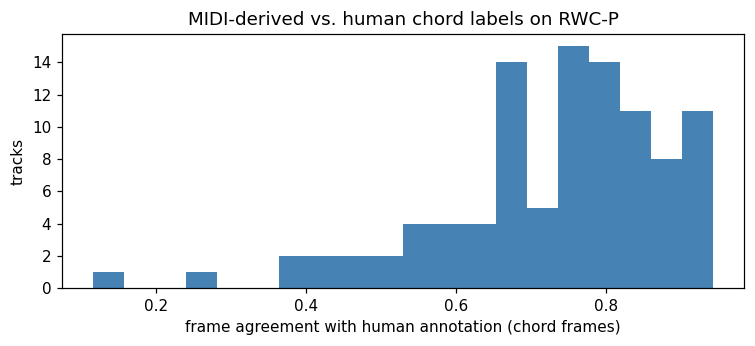

In [4]:
grid = 0.1
rows = []
for pid in data.track_ids("P", ann):
    b, bp = data.load_beats(pid, ann)
    ref_iv, ref_lab = data.load_chords(pid, ann)
    t = np.arange(0.0, ref_iv[-1, 1], grid) + grid / 2
    truth = evaluate.labels_to_frames(ref_iv, ref_lab, t, reduce="quality")
    est_iv, est_lab, _ = midi_chords.derive_chords(data.midi_path(pid, ann), b, bp, grid="beat", end_time=ref_iv[-1, 1])
    est = evaluate.labels_to_frames(est_iv, est_lab, t, reduce=None)
    chord_frames = truth != -1
    import mir_eval.chord as mc
    qualities = [mc.split(l)[1] for l in ref_lab if mc.split(l)[0] not in ("N", "X")]
    rows.append({"track": pid, "title": meta.loc[pid, "Title"], "agreement": np.mean(est[chord_frames] == truth[chord_frames]),
                 "derived_N_on_chord_frames": np.mean(est[chord_frames] == -1),
                 "share_plain_maj_min": np.mean([q in ("maj", "min") for q in qualities]),
                 "midi_tracks": len(midi_chords.load_midi(data.midi_path(pid, ann)).instruments)})
val = pd.DataFrame(rows).set_index("track")
print(f"frame agreement with human major/minor labels: mean {val['agreement'].mean():.3f}, median {val['agreement'].median():.3f}")
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(val["agreement"], bins=20, color="steelblue")
ax.set(xlabel="frame agreement with human annotation (chord frames)", ylabel="tracks", title="MIDI-derived vs. human chord labels on RWC-P")
plt.show()

In [5]:
print("Best agreement:")
display(val.sort_values("agreement", ascending=False).head(5).round(3))
print("Worst agreement:")
display(val.sort_values("agreement").head(5).round(3))

Best agreement:


,title,agreement,derived_N_on_chord_frames,share_plain_maj_min,midi_tracks
track,,,,,
RWC_P074,Kimi no iro,0.942,0.000,0.748,5
RWC_P085,Waiting for the moment,0.928,0.000,0.933,16
RWC_P069,Gin no sora,0.924,0.003,0.255,15
RWC_P055,First Love,0.918,0.000,0.784,14
RWC_P086,Angel Baby,0.916,0.000,0.885,12


Worst agreement:


,title,agreement,derived_N_on_chord_frames,share_plain_maj_min,midi_tracks
track,,,,,
RWC_P015,old fashioned,0.116,0.655,0.852,15
RWC_P031,Moving Round and Round,0.275,0.020,0.992,16
RWC_P006,Funky Life,0.378,0.038,0.023,23
RWC_P025,tell me,0.390,0.016,0.131,18
RWC_P061,FOR YOU,0.432,0.007,0.476,15


Roughly **three quarters** of the chord frames agree. Is that good? Chord labelling is interpretive: when several people annotate the *same* pop songs, they too agree on only about three quarters of the frames at the major/minor level (Koops et al., 2019). The disagreements here are instructive:

* The worst tracks have **sparse MIDI** (e.g. only a piano and a melody, no bass) and **jazz harmony**: a human hears `Bb:maj9`, the MIDI piano plays a rootless voicing F–A♭–C–D, and the templates answer `F:min`. Without a bass there is nothing to break the tie.
* Sevenths and sixths are inherently ambiguous for triad templates (`A:min7` ⊃ `C:maj`); the bass bonus resolves most of them, not all.
* Humans annotate at a coarser rhythm than the beat and smooth over passing chords.

RWC-R is a friendlier case: full arrangements with a real bass line, diatonic children's songs, few sevenths. We cannot measure the agreement there (no humans annotated it), but every failure mode above is *less* present.

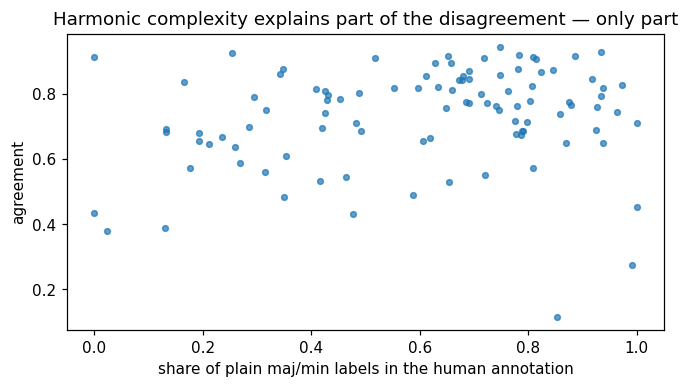

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(val["share_plain_maj_min"], val["agreement"], s=14, alpha=0.7)
ax.set(xlabel="share of plain maj/min labels in the human annotation", ylabel="agreement", title="Harmonic complexity explains part of the disagreement — only part")
plt.show()

## 7.3 Derive the RWC-R chord labels

Now the real purpose: produce chord labels for the 15 RWC-R tracks and save them in the annotation repository's own format (`t_start;t_end;chord`). They go to `derived_annotations/chords_from_midi/RWC-R/` inside this repository, so that notebook 8 — and any reader — can use them without re-running this notebook.

In [7]:
out_dir = root / "derived_annotations" / "chords_from_midi"
summary = []
for rid in data.track_ids("R", ann):
    b, bp = data.load_beats(rid, ann)
    iv, lab, conf = midi_chords.derive_chords(data.midi_path(rid, ann), b, bp, grid="beat", end_time=float(meta.loc[rid, "audio_end"]))
    data.save_chords(out_dir / "RWC-R" / f"{rid}.csv", iv, lab)
    is_chord = np.array([l != "N" for l in lab])
    summary.append({"track": rid, "title": meta.loc[rid, "Title"], "segments": len(lab), "N segments": int((~is_chord).sum()),
                    "distinct chords": len(set(lab) - {"N"}), "mean chord duration (s)": (iv[is_chord, 1] - iv[is_chord, 0]).mean(),
                    "mean confidence": conf[is_chord].mean()})
summary = pd.DataFrame(summary).set_index("track")
summary.round(2)

,title,segments,N segments,distinct chords,mean chord duration (s),mean confidence
track,,,,,,
RWC_R001,Chou chou,66,0,8,1.87,0.81
RWC_R002,Musunde hiraite,50,1,7,2.53,0.85
RWC_R003,Akai kutsu,61,0,7,2.85,0.79
RWC_R004,Nanatsu no ko,58,3,12,2.22,0.83
RWC_R005,Momotaro,96,4,13,1.34,0.83
RWC_R006,Jingle Bells,69,5,8,1.74,0.79
RWC_R007,Mary Had A Little Lamb,49,2,9,2.53,0.82
RWC_R008,I've Been Workin' On The Railroad,80,5,11,1.55,0.84
RWC_R009,Home on the Range,65,1,9,2.35,0.85


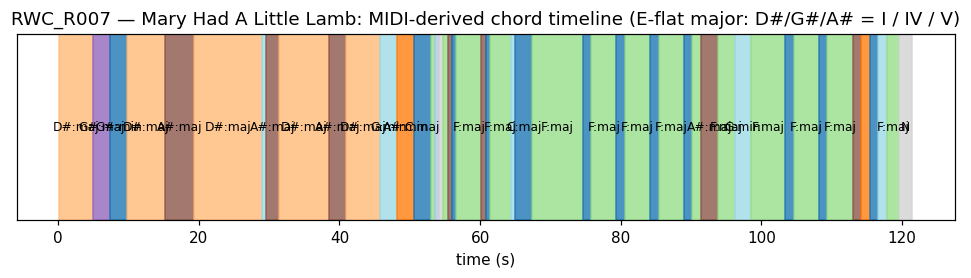

In [8]:
rid = "RWC_R007"
iv, lab = data.load_chords(rid, derived_dir=out_dir)
fig, ax = plt.subplots(figsize=(11, 2.2))
for (s, e), l in zip(iv, lab):
    ax.axvspan(s, e, color=("lightgrey" if l == "N" else plt.cm.tab20(templates.label_to_index(l) % 20)), alpha=0.8)
    if e - s > 1.5:
        ax.text((s + e) / 2, 0.5, l, ha="center", va="center", fontsize=8)
ax.set(yticks=[], xlabel="time (s)", title=f"{rid} — {meta.loc[rid, 'Title']}: MIDI-derived chord timeline (E-flat major: D#/G#/A# = I / IV / V)")
plt.show()

Children's songs indeed: 7–14 distinct chords per track, mostly I–IV–V, and chord durations of 1.3–3.2 s — long enough for the HMM to accumulate evidence between changes (notebook 6). Keep this table in mind when reading Table I in the next notebook: the paper's best track, *Silent Night* (`RWC_R013`), has the longest chords, and its weakest (`RWC_R006`, `RWC_R008`) are among the fastest.

> **Transparency note.** The paper does not state how its RWC-R chord labels were produced. Ours are one reasonable reconstruction; another choice of grid, bass weight or template set would change some segments and therefore some decimals in Table I. That is not a flaw of either — it is what "reproducing" a paper with an under-specified ground truth means, and it is why this repository ships the labels and the code that made them.

## Exercises

1. Repeat the RWC-P validation with `grid="bar"`. Agreement drops — why might humans still prefer bar-level labels?
2. Set `bass_bonus=0.0` and `exclude_names=()` (keep the melody). Which change matters more?
3. `RWC_R004` and `RWC_R013` have no live instruments and no drums (see `metadata.csv`). Are their derived labels more or less confident than the rest? Form a hypothesis before you look.